<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

## **Optimising Marketing with Artificial Intelligence (OMAI)**

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

### **Machine Learning Recommendation Models**

---

<style> 
h1, h1 *,  
h2, h2 *,  
h3, h3 *,  
h4, h4 *,  
h5, h5 *,  
h6, h6 * {   
  font-family: "Times New Roman", Times, serif !important; 
} 
</style>  

#### **Machine Learning Recommendation Models - Term Frequency-Inverse Document Frequency**

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

OMAI_mlrm = pd.read_csv('OMAI - Data - Machine Learning Recommendation Models (MLRMs).csv')
OMAI_mlrm = OMAI_mlrm.drop('Unnamed: 0', axis = 1)
OMAI_mlrm.iloc[0:5]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words = 'english')
OMAI_mlrm['description'] = OMAI_mlrm['description'].fillna('')
tfidf_matrix = tfidf.fit_transform(OMAI_mlrm['description'])
tfidf_matrix.shape
tfidf_array = tfidf_matrix.toarray()
print(tfidf_array)

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.08787128 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


--

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

#### **Machine Learning Recommendation Models - Logistic Regression**

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from scipy.sparse import hstack, csr_matrix

In [ ]:
from scipy.sparse import csr_matrix, hstack

features = ['price_normalised', 'adjusted_average_bert_pred_prob_pos',
            'console_Game Boy Advance', 'console_Game Boy Color', 'console_GameCube',
            'console_Nintendo 64', 'console_Nintendo DS', 'console_Nintendo Wii',
            'console_PC & Mac', 'console_PlayStation', 'console_PlayStation 2',
            'console_Sega Genesis', 'console_PlayStation 3', 'console_PlayStation Portable',
            'console_Sega Dreamcast', 'console_Super Nintendo', 'console_Xbox', 'console_Xbox 360']

X_numerical = OMAI_mlrm[features].values     
X_numerical_sparse = csr_matrix(X_numerical)          
X_sparse = hstack([X_numerical_sparse, tfidf_matrix])
X = X_sparse.toarray().astype(np.float32)
y = OMAI_mlrm['adjusted_average_sentiment_score']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 16, stratify = y)	
print("Training Size X: ",X_train.shape)
print("Training Size y: ",y_train.shape)
print("Test Size X: ",X_test.shape)
print("Test Size y: ",y_test.shape)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import numpy as np

kfcv_pipeline = Pipeline([('smote', SMOTE(random_state = 42)),
                          ('logreg', LogisticRegression(random_state = 16, solver = 'lbfgs', max_iter = 1000, penalty = 'l2'))])

kfcv_logistic = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
kfcv_scores = cross_val_score(kfcv_pipeline, X, y, cv = kfcv_logistic, scoring = 'accuracy', n_jobs = -1)

print(f'Cross-Validation Accuracy Scores: {kfcv_scores}')
print(f'Average Accuracy: {np.mean(kfcv_scores):.4f}')

kfcv_pipeline.fit(X_train, y_train)
y_test_pred = kfcv_pipeline.predict(X_test)

Cross-Validation Accuracy Scores: [0.82978723 0.90070922 0.82978723 0.90070922 0.79432624 0.88652482
 0.84397163 0.85106383 0.84397163 0.90070922]
Average Accuracy: 0.8582


In [6]:
from sklearn.metrics import roc_auc_score, roc_curve

accuracy_test = accuracy_score(y_test, y_test_pred)
print("Test Accuracy: {:.2f}%".format(accuracy_test * 100))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nTest Classification Report:\n", classification_report(y_test, y_test_pred))
y_test_prob = kfcv_pipeline.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_test_prob)
print(f"Test ROC AUC: {roc_auc_test:.4f}")
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

Test Accuracy: 87.23%
Test Confusion Matrix:
 [[ 14  22]
 [ 14 232]]

Test Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.39      0.44        36
           1       0.91      0.94      0.93       246

    accuracy                           0.87       282
   macro avg       0.71      0.67      0.68       282
weighted avg       0.86      0.87      0.87       282

Test ROC AUC: 0.8498


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

y_train_pred = kfcv_pipeline.predict(X_train)
accuracy_train = accuracy_score(y_train, y_train_pred)
print("Training Accuracy: {:.2f}%".format(accuracy_train * 100))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))
y_train_prob = kfcv_pipeline.predict_proba(X_train)[:, 1]
roc_auc_train = roc_auc_score(y_train, y_train_prob)
print(f"Training ROC AUC: {roc_auc_train:.4f}")
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)

Training Accuracy: 96.90%
Training Confusion Matrix:
 [[140   3]
 [ 32 953]]

Training Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.98      0.89       143
           1       1.00      0.97      0.98       985

    accuracy                           0.97      1128
   macro avg       0.91      0.97      0.94      1128
weighted avg       0.97      0.97      0.97      1128

Training ROC AUC: 0.9965


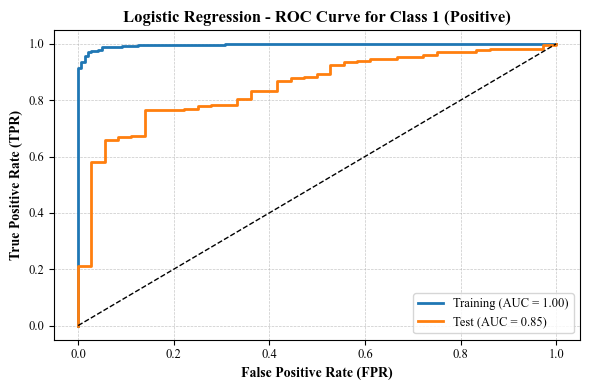

In [10]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize = (6, 4))
ax.plot(fpr_train, tpr_train, label = f'Training (AUC = {roc_auc_train:.2f})', linewidth = 2)
ax.plot(fpr_test, tpr_test, label = f'Test (AUC = {roc_auc_test:.2f})', linewidth = 2)
ax.plot([0, 1], [0, 1], 'k--', linewidth = 1)

ax.set_title("Logistic Regression - ROC Curve for Class 1 (Positive)", fontweight = 'bold', fontsize = 12)
ax.set_xlabel("False Positive Rate (FPR)", fontsize = 10, fontweight = 'bold')
ax.set_ylabel("True Positive Rate (TPR)", fontsize = 10, fontweight = 'bold')
ax.tick_params(axis = 'both', labelsize = 9)
ax.grid(True, linestyle = '--', linewidth = 0.5, alpha = 0.7)
ax.legend(fontsize = 9)

plt.tight_layout()
plt.show()

In [ ]:
logreg_model = kfcv_pipeline.named_steps['logreg']
feature_names_numerical = np.array(features)
tfidf_feature_names = tfidf.get_feature_names_out()

feature_names_complete = np.concatenate([feature_names_numerical, tfidf_feature_names])

coefficients = logreg_model.coef_[0]   
intercept = logreg_model.intercept_[0]

coefficients_df = pd.DataFrame({'feature': feature_names_complete, 'coefficient': coefficients})

coefficients_df_sorted = coefficients_df.sort_values(by = 'coefficient', ascending = False)

print("Intercept:", intercept)
print("\nTop 10 Positive Features:\n", coefficients_df_sorted.head(10))
print("\nTop 10 Negative Features:\n", coefficients_df_sorted.tail(10))

logistic_coefficients_df = coefficients_df_sorted.copy(deep = True)
logistic_coefficients_df.to_csv('OMAI - Data - MLRMs (Logistic Regression) (Coefficients).csv')

Intercept: -5.435545411223203

Top 10 Positive Features:
                                    feature  coefficient
1      adjusted_average_bert_pred_prob_pos    11.912290
4                         console_GameCube     1.220160
20092                                story     0.914452
7433                             expansion     0.899242
15762                              players     0.754524
18985                                 sims     0.744035
3497                                   car     0.722230
16                            console_Xbox     0.719125
7991                                 final     0.717188
6896                                empire     0.709651

Top 10 Negative Features:
             feature  coefficient
15592          ping    -1.033781
5725   demonhaunted    -1.036472
427              3d    -1.158287
23827           zoo    -1.209206
21673  transformers    -1.224386
12044      legendia    -1.248906
65               08    -1.586227
3922          chess    -1.646333
1

In [ ]:
OMAI_mlrm['logreg_prob'] = kfcv_pipeline.predict_proba(X)[:, 1]

In [ ]:
OMAI_mlrm_logreg = OMAI_mlrm.copy(deep = True)
OMAI_mlrm_logreg.to_csv('OMAI - Results - MLRMs (Logistic Regression) (Predictions).csv')

--

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

#### **Machine Learning Recommendation Models - K-Nearest Neighbours & Manhattan Distance**

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

OMAI_mlrm_knn = pd.read_csv('OMAI - Results - MLRMs (Logistic Regression) (Predictions).csv')
OMAI_mlrm_knn = OMAI_mlrm_knn.drop('Unnamed: 0', axis = 1)
OMAI_mlrm_knn.iloc[0:5]

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from scipy.sparse import hstack, csr_matrix

In [ ]:
from scipy.sparse import csr_matrix, hstack

features2 = ['price_normalised', 'adjusted_average_bert_pred_prob_pos',
             'console_Game Boy Advance', 'console_Game Boy Color', 'console_GameCube',
             'console_Nintendo 64', 'console_Nintendo DS', 'console_Nintendo Wii',
             'console_PC & Mac', 'console_PlayStation', 'console_PlayStation 2',
             'console_Sega Genesis', 'console_PlayStation 3', 'console_PlayStation Portable',
             'console_Sega Dreamcast', 'console_Super Nintendo', 'console_Xbox', 'console_Xbox 360']

X_numerical2 = OMAI_mlrm[features2].values     
X_numerical_sparse2 = csr_matrix(X_numerical2)          
X_sparse2 = hstack([X_numerical_sparse2, tfidf_matrix])
X2 = X_sparse2.toarray().astype(np.float32)
y2 = OMAI_mlrm['adjusted_average_sentiment_score']  

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.20, random_state = 16, stratify = y2)	
print("Training Size X : ",X_train2.shape)
print("Training Size  y : ",y_train2.shape)
print("Test Size X : ",X_test2.shape)
print("Test Size y : ",y_test2.shape)

from imblearn.over_sampling import SMOTE

smote_knn = SMOTE(random_state = 42)
X_train_resampled2, y_train_resampled2 = smote_knn.fit_resample(X_train2, y_train2)

Training Size X :  (1128, 23846)
Training Size  y :  (1128,)
Test Size X :  (282, 23846)
Test Size y :  (282,)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

kfcv_knn = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)

error = []
ks = list(range(1, 50))

for k in ks:
    kfcv_pipeline2 = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                       ("knn", KNeighborsClassifier(n_neighbors = k, metric = "minkowski", p = 1))])

    scores2 = cross_val_score(kfcv_pipeline2, X_train2, y_train2, cv = kfcv_knn,
                             scoring = 'accuracy', n_jobs = -1)
    error.append(1 - scores2.mean())

plt.figure(figsize = (9, 4))
plt.plot(ks, error, color = '#FF8C00', linestyle = 'dashed', marker = 'o',
         markerfacecolor = 'purple', markeredgecolor = '#FF8C00', markersize = 10)
plt.title('K-Nearest Neighbours - Optimisation of K Value', fontweight = 'bold', fontsize = 12)
plt.xlabel('K Value', fontweight = 'bold', fontsize = 10)
plt.ylabel('Mean Error', fontweight = 'bold', fontsize = 10)
for k, e in zip(ks, error):
    plt.annotate(str(k), (k, e), textcoords = 'offset points', xytext = (0, 8),
                 ha = 'center', fontsize = 6)
plt.tight_layout()
plt.show()

In [16]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

knn_classifierk1m = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 1, metric = 'minkowski', p = 1))])

knn_classifierk1m.fit(X_train2, y_train2)  
y_test_predk1m = knn_classifierk1m.predict(X_test2)

y_test_predk1m = knn_classifierk1m.predict(X_test2)                
accuracy_testk1m = accuracy_score(y_test2, y_test_predk1m)
print("Test Accuracy - K1M: {:.2f}%".format(accuracy_testk1m * 100))
print("Test Confusion Matrix - K1M:\n", confusion_matrix(y_test2, y_test_predk1m))
print("\nTest Classification Report - K1M:\n", classification_report(y_test2, y_test_predk1m))
y_test_probk1m = knn_classifierk1m.predict_proba(X_test2)[:, 1]     
roc_auc_testk1m = roc_auc_score(y_test2, y_test_probk1m)
print(f"Test ROC AUC - K1M: {roc_auc_testk1m:.4f}")
fpr_testk1m, tpr_testk1m, _ = roc_curve(y_test2, y_test_probk1m)

Test Accuracy - K1M: 81.56%
Test Confusion Matrix - K1M:
 [[  5  31]
 [ 21 225]]

Test Classification Report - K1M:
               precision    recall  f1-score   support

           0       0.19      0.14      0.16        36
           1       0.88      0.91      0.90       246

    accuracy                           0.82       282
   macro avg       0.54      0.53      0.53       282
weighted avg       0.79      0.82      0.80       282

Test ROC AUC - K1M: 0.5268


In [17]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

knn_classifierk2m = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 2, metric = 'minkowski', p = 1))])

knn_classifierk2m.fit(X_train2, y_train2)  
y_test_predk2m = knn_classifierk2m.predict(X_test2)

y_test_predk2m = knn_classifierk2m.predict(X_test2)                
accuracy_testk2m = accuracy_score(y_test2, y_test_predk2m)
print("Test Accuracy - K2M: {:.2f}%".format(accuracy_testk2m * 100))
print("Test Confusion Matrix - K2M:\n", confusion_matrix(y_test2, y_test_predk2m))
print("\nTest Classification Report - K2M:\n", classification_report(y_test2, y_test_predk2m))
y_test_probk2m = knn_classifierk2m.predict_proba(X_test2)[:, 1]     
roc_auc_testk2m = roc_auc_score(y_test2, y_test_probk2m)
print(f"Test ROC AUC - K2M: {roc_auc_testk2m:.4f}")
fpr_testk2m, tpr_testk2m, _ = roc_curve(y_test2, y_test_probk2m)

Test Accuracy - K2M: 75.53%
Test Confusion Matrix - K2M:
 [[  7  29]
 [ 40 206]]

Test Classification Report - K2M:
               precision    recall  f1-score   support

           0       0.15      0.19      0.17        36
           1       0.88      0.84      0.86       246

    accuracy                           0.76       282
   macro avg       0.51      0.52      0.51       282
weighted avg       0.78      0.76      0.77       282

Test ROC AUC - K2M: 0.5197


In [18]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

knn_classifierk3m = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 3, metric = 'minkowski', p = 1))])

knn_classifierk3m.fit(X_train2, y_train2)  
y_test_predk3m = knn_classifierk3m.predict(X_test2)

y_test_predk3m = knn_classifierk3m.predict(X_test2)                
accuracy_testk3m = accuracy_score(y_test2, y_test_predk3m)
print("Test Accuracy - K3M: {:.2f}%".format(accuracy_testk3m * 100))
print("Test Confusion Matrix - K3M:\n", confusion_matrix(y_test2, y_test_predk3m))
print("\nTest Classification Report - K3M:\n", classification_report(y_test2, y_test_predk3m))
y_test_probk3m = knn_classifierk3m.predict_proba(X_test2)[:, 1]     
roc_auc_testk3m = roc_auc_score(y_test2, y_test_probk3m)
print(f"Test ROC AUC - K3M: {roc_auc_testk3m:.4f}")
fpr_testk3m, tpr_testk3m, _ = roc_curve(y_test2, y_test_probk3m)

Test Accuracy - K3M: 76.24%
Test Confusion Matrix - K3M:
 [[  5  31]
 [ 36 210]]

Test Classification Report - K3M:
               precision    recall  f1-score   support

           0       0.12      0.14      0.13        36
           1       0.87      0.85      0.86       246

    accuracy                           0.76       282
   macro avg       0.50      0.50      0.50       282
weighted avg       0.78      0.76      0.77       282

Test ROC AUC - K3M: 0.5343


In [19]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

knn_classifierk4m = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 4, metric = 'minkowski', p = 1))])

knn_classifierk4m.fit(X_train2, y_train2)  
y_test_predk4m = knn_classifierk4m.predict(X_test2)

y_test_predk4m = knn_classifierk4m.predict(X_test2)                
accuracy_testk4m = accuracy_score(y_test2, y_test_predk4m)
print("Test Accuracy - K4M: {:.2f}%".format(accuracy_testk4m * 100))
print("Test Confusion Matrix - K4M:\n", confusion_matrix(y_test2, y_test_predk4m))
print("\nTest Classification Report - K4M:\n", classification_report(y_test2, y_test_predk4m))
y_test_probk4m = knn_classifierk4m.predict_proba(X_test2)[:, 1]     
roc_auc_testk4m = roc_auc_score(y_test2, y_test_probk4m)
print(f"Test ROC AUC - K4M: {roc_auc_testk4m:.4f}")
fpr_testk4m, tpr_testk4m, _ = roc_curve(y_test2, y_test_probk4m)

Test Accuracy - K4M: 58.16%
Test Confusion Matrix - K4M:
 [[ 24  12]
 [106 140]]

Test Classification Report - K4M:
               precision    recall  f1-score   support

           0       0.18      0.67      0.29        36
           1       0.92      0.57      0.70       246

    accuracy                           0.58       282
   macro avg       0.55      0.62      0.50       282
weighted avg       0.83      0.58      0.65       282

Test ROC AUC - K4M: 0.5967


In [20]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

knn_classifierk5m = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 1))])

knn_classifierk5m.fit(X_train2, y_train2)  
y_test_predk5m = knn_classifierk5m.predict(X_test2)

y_test_predk5m = knn_classifierk5m.predict(X_test2)                
accuracy_testk5m = accuracy_score(y_test2, y_test_predk5m)
print("Test Accuracy - K5M: {:.2f}%".format(accuracy_testk5m * 100))
print("Test Confusion Matrix - K5M:\n", confusion_matrix(y_test2, y_test_predk5m))
print("\nTest Classification Report - K5M:\n", classification_report(y_test2, y_test_predk5m))
y_test_probk5m = knn_classifierk5m.predict_proba(X_test2)[:, 1]     
roc_auc_testk5m = roc_auc_score(y_test2, y_test_probk5m)
print(f"Test ROC AUC - K5M: {roc_auc_testk5m:.4f}")
fpr_testk5m, tpr_testk5m, _ = roc_curve(y_test2, y_test_probk5m)

Test Accuracy - K5M: 67.73%
Test Confusion Matrix - K5M:
 [[ 20  16]
 [ 75 171]]

Test Classification Report - K5M:
               precision    recall  f1-score   support

           0       0.21      0.56      0.31        36
           1       0.91      0.70      0.79       246

    accuracy                           0.68       282
   macro avg       0.56      0.63      0.55       282
weighted avg       0.82      0.68      0.73       282

Test ROC AUC - K5M: 0.6168


In [21]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk6m = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 6, metric = 'minkowski', p = 1))])

knn_classifierk6m.fit(X_train2, y_train2)
y_test_predk6m = knn_classifierk6m.predict(X_test2)

y_test_predk6m = knn_classifierk6m.predict(X_test2)
accuracy_testk6m = accuracy_score(y_test2, y_test_predk6m)
print("Test Accuracy - K6M: {:.2f}%".format(accuracy_testk6m * 100))
print("Test Confusion Matrix - K6M:\n", confusion_matrix(y_test2, y_test_predk6m))
print("\nTest Classification Report - K6M:\n", classification_report(y_test2, y_test_predk6m))
y_test_probk6m = knn_classifierk6m.predict_proba(X_test2)[:, 1]
roc_auc_testk6m = roc_auc_score(y_test2, y_test_probk6m)
print(f"Test ROC AUC - K6M: {roc_auc_testk6m:.4f}")
fpr_testk6m, tpr_testk6m, _ = roc_curve(y_test2, y_test_probk6m)

Test Accuracy - K6M: 42.20%
Test Confusion Matrix - K6M:
 [[ 28   8]
 [155  91]]

Test Classification Report - K6M:
               precision    recall  f1-score   support

           0       0.15      0.78      0.26        36
           1       0.92      0.37      0.53       246

    accuracy                           0.42       282
   macro avg       0.54      0.57      0.39       282
weighted avg       0.82      0.42      0.49       282

Test ROC AUC - K6M: 0.5989


In [22]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk7m = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 1))])

knn_classifierk7m.fit(X_train2, y_train2)
y_test_predk7m = knn_classifierk7m.predict(X_test2)

y_test_predk7m = knn_classifierk7m.predict(X_test2)
accuracy_testk7m = accuracy_score(y_test2, y_test_predk7m)
print("Test Accuracy - K7M: {:.2f}%".format(accuracy_testk7m * 100))
print("Test Confusion Matrix - K7M:\n", confusion_matrix(y_test2, y_test_predk7m))
print("\nTest Classification Report - K7M:\n", classification_report(y_test2, y_test_predk7m))
y_test_probk7m = knn_classifierk7m.predict_proba(X_test2)[:, 1]
roc_auc_testk7m = roc_auc_score(y_test2, y_test_probk7m)
print(f"Test ROC AUC - K7M: {roc_auc_testk7m:.4f}")
fpr_testk7m, tpr_testk7m, _ = roc_curve(y_test2, y_test_probk7m)

Test Accuracy - K7M: 52.84%
Test Confusion Matrix - K7M:
 [[ 27   9]
 [124 122]]

Test Classification Report - K7M:
               precision    recall  f1-score   support

           0       0.18      0.75      0.29        36
           1       0.93      0.50      0.65       246

    accuracy                           0.53       282
   macro avg       0.56      0.62      0.47       282
weighted avg       0.84      0.53      0.60       282

Test ROC AUC - K7M: 0.6112


In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk8m = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 8, metric = 'minkowski', p = 1))])

knn_classifierk8m.fit(X_train2, y_train2)
y_test_predk8m = knn_classifierk8m.predict(X_test2)

y_test_predk8m = knn_classifierk8m.predict(X_test2)
accuracy_testk8m = accuracy_score(y_test2, y_test_predk8m)
print("Test Accuracy - K8M: {:.2f}%".format(accuracy_testk8m * 100))
print("Test Confusion Matrix - K8M:\n", confusion_matrix(y_test2, y_test_predk8m))
print("\nTest Classification Report - K8M:\n", classification_report(y_test2, y_test_predk8m))
y_test_probk8m = knn_classifierk8m.predict_proba(X_test2)[:, 1]
roc_auc_testk8m = roc_auc_score(y_test2, y_test_probk8m)
print(f"Test ROC AUC - K8M: {roc_auc_testk8m:.4f}")
fpr_testk8m, tpr_testk8m, _ = roc_curve(y_test2, y_test_probk8m)

Test Accuracy - K8M: 17.73%
Test Confusion Matrix - K8M:
 [[ 34   2]
 [230  16]]

Test Classification Report - K8M:
               precision    recall  f1-score   support

           0       0.13      0.94      0.23        36
           1       0.89      0.07      0.12       246

    accuracy                           0.18       282
   macro avg       0.51      0.50      0.17       282
weighted avg       0.79      0.18      0.13       282

Test ROC AUC - K8M: 0.6051


In [24]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk9m = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 9, metric = 'minkowski', p = 1))])

knn_classifierk9m.fit(X_train2, y_train2)
y_test_predk9m = knn_classifierk9m.predict(X_test2)

y_test_predk9m = knn_classifierk9m.predict(X_test2)
accuracy_testk9m = accuracy_score(y_test2, y_test_predk9m)
print("Test Accuracy - K9M: {:.2f}%".format(accuracy_testk9m * 100))
print("Test Confusion Matrix - K9M:\n", confusion_matrix(y_test2, y_test_predk9m))
print("\nTest Classification Report - K9M:\n", classification_report(y_test2, y_test_predk9m))
y_test_probk9m = knn_classifierk9m.predict_proba(X_test2)[:, 1]
roc_auc_testk9m = roc_auc_score(y_test2, y_test_probk9m)
print(f"Test ROC AUC - K9M: {roc_auc_testk9m:.4f}")
fpr_testk9m, tpr_testk9m, _ = roc_curve(y_test2, y_test_probk9m)

Test Accuracy - K9M: 18.09%
Test Confusion Matrix - K9M:
 [[ 34   2]
 [229  17]]

Test Classification Report - K9M:
               precision    recall  f1-score   support

           0       0.13      0.94      0.23        36
           1       0.89      0.07      0.13       246

    accuracy                           0.18       282
   macro avg       0.51      0.51      0.18       282
weighted avg       0.80      0.18      0.14       282

Test ROC AUC - K9M: 0.5864


In [25]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk10m = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                       ("knn", KNeighborsClassifier(n_neighbors = 10, metric = 'minkowski', p = 1))])

knn_classifierk10m.fit(X_train2, y_train2)
y_test_predk10m = knn_classifierk10m.predict(X_test2)

y_test_predk10m = knn_classifierk10m.predict(X_test2)
accuracy_testk10m = accuracy_score(y_test2, y_test_predk10m)
print("Test Accuracy - K10M: {:.2f}%".format(accuracy_testk10m * 100))
print("Test Confusion Matrix - K10M:\n", confusion_matrix(y_test2, y_test_predk10m))
print("\nTest Classification Report - K10M:\n", classification_report(y_test2, y_test_predk10m))
y_test_probk10m = knn_classifierk10m.predict_proba(X_test2)[:, 1]
roc_auc_testk10m = roc_auc_score(y_test2, y_test_probk10m)
print(f"Test ROC AUC - K10M: {roc_auc_testk10m:.4f}")
fpr_testk10m, tpr_testk10m, _ = roc_curve(y_test2, y_test_probk10m)

Test Accuracy - K10M: 14.18%
Test Confusion Matrix - K10M:
 [[ 34   2]
 [240   6]]

Test Classification Report - K10M:
               precision    recall  f1-score   support

           0       0.12      0.94      0.22        36
           1       0.75      0.02      0.05       246

    accuracy                           0.14       282
   macro avg       0.44      0.48      0.13       282
weighted avg       0.67      0.14      0.07       282

Test ROC AUC - K10M: 0.5998


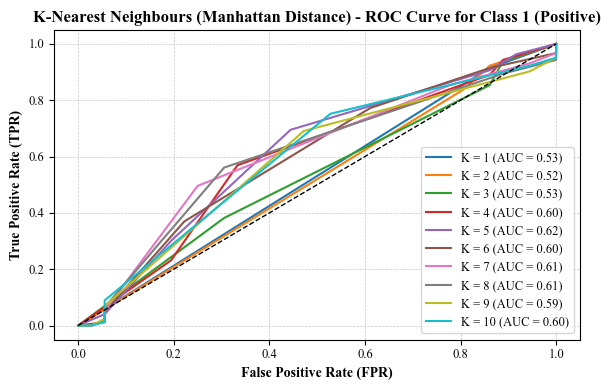

In [27]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize = (6, 4))
ax.plot(fpr_testk1m, tpr_testk1m, label = f'K = 1 (AUC = {roc_auc_testk1m:.2f})', linewidth = 1.5)
ax.plot(fpr_testk2m, tpr_testk2m, label = f'K = 2 (AUC = {roc_auc_testk2m:.2f})', linewidth = 1.5)
ax.plot(fpr_testk3m, tpr_testk3m, label = f'K = 3 (AUC = {roc_auc_testk3m:.2f})', linewidth = 1.5)
ax.plot(fpr_testk4m, tpr_testk4m, label = f'K = 4 (AUC = {roc_auc_testk4m:.2f})', linewidth = 1.5)
ax.plot(fpr_testk5m, tpr_testk5m, label = f'K = 5 (AUC = {roc_auc_testk5m:.2f})', linewidth = 1.5)
ax.plot(fpr_testk6m, tpr_testk6m, label = f'K = 6 (AUC = {roc_auc_testk6m:.2f})', linewidth = 1.5)
ax.plot(fpr_testk7m, tpr_testk7m, label = f'K = 7 (AUC = {roc_auc_testk7m:.2f})', linewidth = 1.5)
ax.plot(fpr_testk8m, tpr_testk8m, label = f'K = 8 (AUC = {roc_auc_testk8m:.2f})', linewidth = 1.5)
ax.plot(fpr_testk9m, tpr_testk9m, label = f'K = 9 (AUC = {roc_auc_testk9m:.2f})', linewidth = 1.5)
ax.plot(fpr_testk10m, tpr_testk10m, label = f'K = 10 (AUC = {roc_auc_testk10m:.2f})', linewidth = 1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth = 1)

ax.set_title("K-Nearest Neighbours (Manhattan Distance) - ROC Curve for Class 1 (Positive)", fontweight = 'bold', fontsize = 12)
ax.set_xlabel("False Positive Rate (FPR)", fontsize = 10, fontweight = 'bold')
ax.set_ylabel("True Positive Rate (TPR)", fontsize = 10, fontweight = 'bold')
ax.tick_params(axis = 'both', labelsize = 9)
ax.grid(True, linestyle = '--', linewidth = 0.5, alpha = 0.7)
ax.legend(fontsize = 9, loc = 'lower right')

plt.tight_layout()
plt.show()

--

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

#### **Machine Learning Recommendation Models - K-Nearest Neighbours & Euclidean Distance**

In [28]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk1e = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 1, metric = 'minkowski', p = 2))])  

knn_classifierk1e.fit(X_train2, y_train2)
y_test_predk1e = knn_classifierk1e.predict(X_test2)

y_test_predk1e = knn_classifierk1e.predict(X_test2)
accuracy_testk1e = accuracy_score(y_test2, y_test_predk1e)
print("Test Accuracy - K1E: {:.2f}%".format(accuracy_testk1e * 100))
print("Test Confusion Matrix - K1E:\n", confusion_matrix(y_test2, y_test_predk1e))
print("\nTest Classification Report - K1E:\n", classification_report(y_test2, y_test_predk1e))
y_test_probk1e = knn_classifierk1e.predict_proba(X_test2)[:, 1]
roc_auc_testk1e = roc_auc_score(y_test2, y_test_probk1e)
print(f"Test ROC AUC - K1E: {roc_auc_testk1e:.4f}")
fpr_testk1e, tpr_testk1e, _ = roc_curve(y_test2, y_test_probk1e)

Test Accuracy - K1E: 28.37%
Test Confusion Matrix - K1E:
 [[ 31   5]
 [197  49]]

Test Classification Report - K1E:
               precision    recall  f1-score   support

           0       0.14      0.86      0.23        36
           1       0.91      0.20      0.33       246

    accuracy                           0.28       282
   macro avg       0.52      0.53      0.28       282
weighted avg       0.81      0.28      0.31       282

Test ROC AUC - K1E: 0.5301


In [29]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk2e = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 2, metric = 'minkowski', p = 2))])  

knn_classifierk2e.fit(X_train2, y_train2)
y_test_predk2e = knn_classifierk2e.predict(X_test2)

y_test_predk2e = knn_classifierk2e.predict(X_test2)
accuracy_testk2e = accuracy_score(y_test2, y_test_predk2e)
print("Test Accuracy - K2E: {:.2f}%".format(accuracy_testk2e * 100))
print("Test Confusion Matrix - K2E:\n", confusion_matrix(y_test2, y_test_predk2e))
print("\nTest Classification Report - K2E:\n", classification_report(y_test2, y_test_predk2e))
y_test_probk2e = knn_classifierk2e.predict_proba(X_test2)[:, 1]
roc_auc_testk2e = roc_auc_score(y_test2, y_test_probk2e)
print(f"Test ROC AUC - K2E: {roc_auc_testk2e:.4f}")
fpr_testk2e, tpr_testk2e, _ = roc_curve(y_test2, y_test_probk2e)

Test Accuracy - K2E: 15.60%
Test Confusion Matrix - K2E:
 [[ 33   3]
 [235  11]]

Test Classification Report - K2E:
               precision    recall  f1-score   support

           0       0.12      0.92      0.22        36
           1       0.79      0.04      0.08       246

    accuracy                           0.16       282
   macro avg       0.45      0.48      0.15       282
weighted avg       0.70      0.16      0.10       282

Test ROC AUC - K2E: 0.5115


In [30]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk3e = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 3, metric = 'minkowski', p = 2))])  

knn_classifierk3e.fit(X_train2, y_train2)
y_test_predk3e = knn_classifierk3e.predict(X_test2)

y_test_predk3e = knn_classifierk3e.predict(X_test2)
accuracy_testk3e = accuracy_score(y_test2, y_test_predk3e)
print("Test Accuracy - K3E: {:.2f}%".format(accuracy_testk3e * 100))
print("Test Confusion Matrix - K3E:\n", confusion_matrix(y_test2, y_test_predk3e))
print("\nTest Classification Report - K3E:\n", classification_report(y_test2, y_test_predk3e))
y_test_probk3e = knn_classifierk3e.predict_proba(X_test2)[:, 1]
roc_auc_testk3e = roc_auc_score(y_test2, y_test_probk3e)
print(f"Test ROC AUC - K3E: {roc_auc_testk3e:.4f}")
fpr_testk3e, tpr_testk3e, _ = roc_curve(y_test2, y_test_probk3e)

Test Accuracy - K3E: 18.44%
Test Confusion Matrix - K3E:
 [[ 33   3]
 [227  19]]

Test Classification Report - K3E:
               precision    recall  f1-score   support

           0       0.13      0.92      0.22        36
           1       0.86      0.08      0.14       246

    accuracy                           0.18       282
   macro avg       0.50      0.50      0.18       282
weighted avg       0.77      0.18      0.15       282

Test ROC AUC - K3E: 0.5186


In [31]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk4e = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 4, metric = 'minkowski', p = 2))])  

knn_classifierk4e.fit(X_train2, y_train2)
y_test_predk4e = knn_classifierk4e.predict(X_test2)

y_test_predk4e = knn_classifierk4e.predict(X_test2)
accuracy_testk4e = accuracy_score(y_test2, y_test_predk4e)
print("Test Accuracy - K4E: {:.2f}%".format(accuracy_testk4e * 100))
print("Test Confusion Matrix - K4E:\n", confusion_matrix(y_test2, y_test_predk4e))
print("\nTest Classification Report - K4E:\n", classification_report(y_test2, y_test_predk4e))
y_test_probk4e = knn_classifierk4e.predict_proba(X_test2)[:, 1]
roc_auc_testk4e = roc_auc_score(y_test2, y_test_probk4e)
print(f"Test ROC AUC - K4E: {roc_auc_testk4e:.4f}")
fpr_testk4e, tpr_testk4e, _ = roc_curve(y_test2, y_test_probk4e)

Test Accuracy - K4E: 13.48%
Test Confusion Matrix - K4E:
 [[ 34   2]
 [242   4]]

Test Classification Report - K4E:
               precision    recall  f1-score   support

           0       0.12      0.94      0.22        36
           1       0.67      0.02      0.03       246

    accuracy                           0.13       282
   macro avg       0.39      0.48      0.12       282
weighted avg       0.60      0.13      0.06       282

Test ROC AUC - K4E: 0.5671


In [32]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk5e = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2))])  

knn_classifierk5e.fit(X_train2, y_train2)
y_test_predk5e = knn_classifierk5e.predict(X_test2)

y_test_predk5e = knn_classifierk5e.predict(X_test2)
accuracy_testk5e = accuracy_score(y_test2, y_test_predk5e)
print("Test Accuracy - K5E: {:.2f}%".format(accuracy_testk5e * 100))
print("Test Confusion Matrix - K5E:\n", confusion_matrix(y_test2, y_test_predk5e))
print("\nTest Classification Report - K5E:\n", classification_report(y_test2, y_test_predk5e))
y_test_probk5e = knn_classifierk5e.predict_proba(X_test2)[:, 1]
roc_auc_testk5e = roc_auc_score(y_test2, y_test_probk5e)
print(f"Test ROC AUC - K5E: {roc_auc_testk5e:.4f}")
fpr_testk5e, tpr_testk5e, _ = roc_curve(y_test2, y_test_probk5e)

Test Accuracy - K5E: 15.60%
Test Confusion Matrix - K5E:
 [[ 34   2]
 [236  10]]

Test Classification Report - K5E:
               precision    recall  f1-score   support

           0       0.13      0.94      0.22        36
           1       0.83      0.04      0.08       246

    accuracy                           0.16       282
   macro avg       0.48      0.49      0.15       282
weighted avg       0.74      0.16      0.10       282

Test ROC AUC - K5E: 0.5475


In [33]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk6e = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 6, metric = 'minkowski', p = 2))])  

knn_classifierk6e.fit(X_train2, y_train2)
y_test_predk6e = knn_classifierk6e.predict(X_test2)

y_test_predk6e = knn_classifierk6e.predict(X_test2)
accuracy_testk6e = accuracy_score(y_test2, y_test_predk6e)
print("Test Accuracy - K6E: {:.2f}%".format(accuracy_testk6e * 100))
print("Test Confusion Matrix - K6E:\n", confusion_matrix(y_test2, y_test_predk6e))
print("\nTest Classification Report - K6E:\n", classification_report(y_test2, y_test_predk6e))
y_test_probk6e = knn_classifierk6e.predict_proba(X_test2)[:, 1]
roc_auc_testk6e = roc_auc_score(y_test2, y_test_probk6e)
print(f"Test ROC AUC - K6E: {roc_auc_testk6e:.4f}")
fpr_testk6e, tpr_testk6e, _ = roc_curve(y_test2, y_test_probk6e)

Test Accuracy - K6E: 13.48%
Test Confusion Matrix - K6E:
 [[ 34   2]
 [242   4]]

Test Classification Report - K6E:
               precision    recall  f1-score   support

           0       0.12      0.94      0.22        36
           1       0.67      0.02      0.03       246

    accuracy                           0.13       282
   macro avg       0.39      0.48      0.12       282
weighted avg       0.60      0.13      0.06       282

Test ROC AUC - K6E: 0.5157


In [34]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk7e = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 2))]) 

knn_classifierk7e.fit(X_train2, y_train2)
y_test_predk7e = knn_classifierk7e.predict(X_test2)

y_test_predk7e = knn_classifierk7e.predict(X_test2)
accuracy_testk7e = accuracy_score(y_test2, y_test_predk7e)
print("Test Accuracy - K7E: {:.2f}%".format(accuracy_testk7e * 100))
print("Test Confusion Matrix - K7E:\n", confusion_matrix(y_test2, y_test_predk7e))
print("\nTest Classification Report - K7E:\n", classification_report(y_test2, y_test_predk7e))
y_test_probk7e = knn_classifierk7e.predict_proba(X_test2)[:, 1]
roc_auc_testk7e = roc_auc_score(y_test2, y_test_probk7e)
print(f"Test ROC AUC - K7E: {roc_auc_testk7e:.4f}")
fpr_testk7e, tpr_testk7e, _ = roc_curve(y_test2, y_test_probk7e)

Test Accuracy - K7E: 13.83%
Test Confusion Matrix - K7E:
 [[ 34   2]
 [241   5]]

Test Classification Report - K7E:
               precision    recall  f1-score   support

           0       0.12      0.94      0.22        36
           1       0.71      0.02      0.04       246

    accuracy                           0.14       282
   macro avg       0.42      0.48      0.13       282
weighted avg       0.64      0.14      0.06       282

Test ROC AUC - K7E: 0.5222


In [35]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk8e = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 8, metric = 'minkowski', p = 2))])  

knn_classifierk8e.fit(X_train2, y_train2)
y_test_predk8e = knn_classifierk8e.predict(X_test2)

y_test_predk8e = knn_classifierk8e.predict(X_test2)
accuracy_testk8e = accuracy_score(y_test2, y_test_predk8e)
print("Test Accuracy - K8E: {:.2f}%".format(accuracy_testk8e * 100))
print("Test Confusion Matrix - K8E:\n", confusion_matrix(y_test2, y_test_predk8e))
print("\nTest Classification Report - K8E:\n", classification_report(y_test2, y_test_predk8e))
y_test_probk8e = knn_classifierk8e.predict_proba(X_test2)[:, 1]
roc_auc_testk8e = roc_auc_score(y_test2, y_test_probk8e)
print(f"Test ROC AUC - K8E: {roc_auc_testk8e:.4f}")
fpr_testk8e, tpr_testk8e, _ = roc_curve(y_test2, y_test_probk8e)

Test Accuracy - K8E: 12.77%
Test Confusion Matrix - K8E:
 [[ 34   2]
 [244   2]]

Test Classification Report - K8E:
               precision    recall  f1-score   support

           0       0.12      0.94      0.22        36
           1       0.50      0.01      0.02       246

    accuracy                           0.13       282
   macro avg       0.31      0.48      0.12       282
weighted avg       0.45      0.13      0.04       282

Test ROC AUC - K8E: 0.5069


In [36]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk9e = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                      ("knn", KNeighborsClassifier(n_neighbors = 9, metric = 'minkowski', p = 2))])  

knn_classifierk9e.fit(X_train2, y_train2)
y_test_predk9e = knn_classifierk9e.predict(X_test2)

y_test_predk9e = knn_classifierk9e.predict(X_test2)
accuracy_testk9e = accuracy_score(y_test2, y_test_predk9e)
print("Test Accuracy - K9E: {:.2f}%".format(accuracy_testk9e * 100))
print("Test Confusion Matrix - K9E:\n", confusion_matrix(y_test2, y_test_predk9e))
print("\nTest Classification Report - K9E:\n", classification_report(y_test2, y_test_predk9e))
y_test_probk9e = knn_classifierk9e.predict_proba(X_test2)[:, 1]
roc_auc_testk9e = roc_auc_score(y_test2, y_test_probk9e)
print(f"Test ROC AUC - K9E: {roc_auc_testk9e:.4f}")
fpr_testk9e, tpr_testk9e, _ = roc_curve(y_test2, y_test_probk9e)

Test Accuracy - K9E: 13.12%
Test Confusion Matrix - K9E:
 [[ 34   2]
 [243   3]]

Test Classification Report - K9E:
               precision    recall  f1-score   support

           0       0.12      0.94      0.22        36
           1       0.60      0.01      0.02       246

    accuracy                           0.13       282
   macro avg       0.36      0.48      0.12       282
weighted avg       0.54      0.13      0.05       282

Test ROC AUC - K9E: 0.5159


In [37]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

knn_classifierk10e = Pipeline(steps = [("scaler", StandardScaler()), ("smote", SMOTE(random_state = 42)),
                                       ("knn", KNeighborsClassifier(n_neighbors = 10, metric = 'minkowski', p = 2))])  

knn_classifierk10e.fit(X_train2, y_train2)
y_test_predk10e = knn_classifierk10e.predict(X_test2)

y_test_predk10e = knn_classifierk10e.predict(X_test2)
accuracy_testk10e = accuracy_score(y_test2, y_test_predk10e)
print("Test Accuracy - K10E: {:.2f}%".format(accuracy_testk10e * 100))
print("Test Confusion Matrix - K10E:\n", confusion_matrix(y_test2, y_test_predk10e))
print("\nTest Classification Report - K10E:\n", classification_report(y_test2, y_test_predk10e))
y_test_probk10e = knn_classifierk10e.predict_proba(X_test2)[:, 1]
roc_auc_testk10e = roc_auc_score(y_test2, y_test_probk10e)
print(f"Test ROC AUC - K10E: {roc_auc_testk10e:.4f}")
fpr_testk10e, tpr_testk10e, _ = roc_curve(y_test2, y_test_probk10e)

Test Accuracy - K10E: 12.41%
Test Confusion Matrix - K10E:
 [[ 35   1]
 [246   0]]

Test Classification Report - K10E:
               precision    recall  f1-score   support

           0       0.12      0.97      0.22        36
           1       0.00      0.00      0.00       246

    accuracy                           0.12       282
   macro avg       0.06      0.49      0.11       282
weighted avg       0.02      0.12      0.03       282

Test ROC AUC - K10E: 0.5168


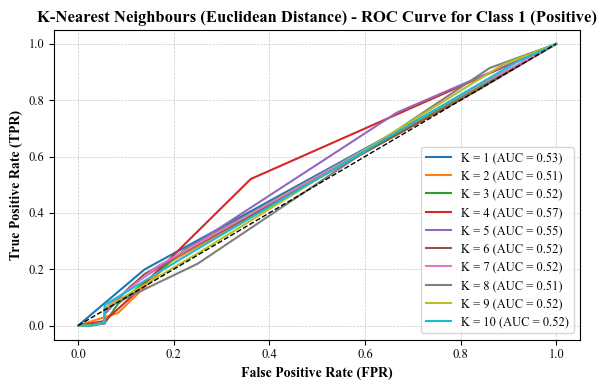

In [38]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize = (6, 4))
ax.plot(fpr_testk1e, tpr_testk1e, label = f'K = 1 (AUC = {roc_auc_testk1e:.2f})', linewidth = 1.5)
ax.plot(fpr_testk2e, tpr_testk2e, label = f'K = 2 (AUC = {roc_auc_testk2e:.2f})', linewidth = 1.5)
ax.plot(fpr_testk3e, tpr_testk3e, label = f'K = 3 (AUC = {roc_auc_testk3e:.2f})', linewidth = 1.5)
ax.plot(fpr_testk4e, tpr_testk4e, label = f'K = 4 (AUC = {roc_auc_testk4e:.2f})', linewidth = 1.5)
ax.plot(fpr_testk5e, tpr_testk5e, label = f'K = 5 (AUC = {roc_auc_testk5e:.2f})', linewidth = 1.5)
ax.plot(fpr_testk6e, tpr_testk6e, label = f'K = 6 (AUC = {roc_auc_testk6e:.2f})', linewidth = 1.5)
ax.plot(fpr_testk7e, tpr_testk7e, label = f'K = 7 (AUC = {roc_auc_testk7e:.2f})', linewidth = 1.5)
ax.plot(fpr_testk8e, tpr_testk8e, label = f'K = 8 (AUC = {roc_auc_testk8e:.2f})', linewidth = 1.5)
ax.plot(fpr_testk9e, tpr_testk9e, label = f'K = 9 (AUC = {roc_auc_testk9e:.2f})', linewidth = 1.5)
ax.plot(fpr_testk10e, tpr_testk10e, label = f'K = 10 (AUC = {roc_auc_testk10e:.2f})', linewidth = 1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth = 1)

ax.set_title("K-Nearest Neighbours (Euclidean Distance) - ROC Curve for Class 1 (Positive)", fontweight = 'bold', fontsize = 12)
ax.set_xlabel("False Positive Rate (FPR)", fontsize = 10, fontweight = 'bold')
ax.set_ylabel("True Positive Rate (TPR)", fontsize = 10, fontweight = 'bold')
ax.tick_params(axis = 'both', labelsize = 9)
ax.grid(True, linestyle = '--', linewidth = 0.5, alpha = 0.7)
ax.legend(fontsize = 9, loc = 'lower right')

plt.tight_layout()
plt.show()

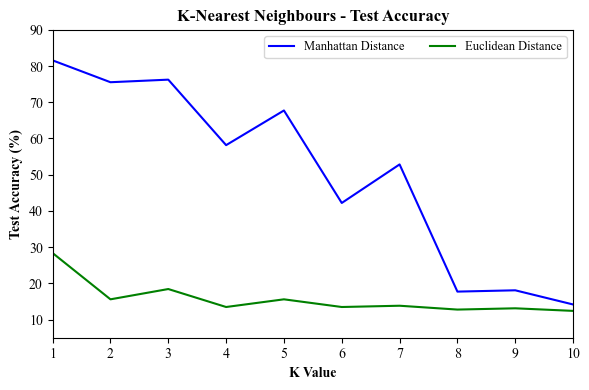

In [40]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'

kvalues = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

manhattantestaccuracy = [81.56, 75.53, 76.24, 58.16, 67.73, 42.20, 52.84, 17.73, 18.09, 14.18] 
euclideantestaccuracy = [28.37, 15.60, 18.44, 13.48, 15.60, 13.48, 13.83, 12.77, 13.12, 12.41] 

fig, ax = plt.subplots(figsize = (6, 4))  
ax.set_title("K-Nearest Neighbours - Test Accuracy", fontweight = 'bold', fontsize = 12)
ax.set_xlabel("K Value", fontsize = 10, fontweight = 'bold')
ax.set_ylabel("Test Accuracy (%)", fontsize = 10, fontweight = 'bold')
ax.tick_params(axis = 'x')

ax.set_xlim(1, 10)
ax.set_xticks(kvalues)
ax.set_ylim(5.0, 90.0)

ax.plot(kvalues, manhattantestaccuracy, label = 'Manhattan Distance', color = 'blue')
ax.plot(kvalues, euclideantestaccuracy, label = 'Euclidean Distance', color = 'green')
ax.legend(fontsize = 9, ncol = 2)
ax.margins(x = 0)

plt.tight_layout()  
plt.show()

--

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

#### **Machine Learning Recommendation Models - Logistic Regression & K-Nearest Neighbours**

In [ ]:
OMAI_mlrm_knn['knnk3m_prob'] = knn_classifierk3m.predict_proba(X2)[:, 1]

In [ ]:
OMAI_mlrm_knn.iloc[0:5]

,productid,title,price,description,console,console_Game Boy Advance,console_Game Boy Color,console_GameCube,console_Nintendo 64,console_Nintendo DS,console_Nintendo Wii,console_PC & Mac,console_PlayStation,console_PlayStation 2,console_PlayStation 3,console_PlayStation Portable,console_Sega Dreamcast,console_Sega Genesis,console_Super Nintendo,console_Xbox,console_Xbox 360,price_normalised,average_score,average_bert_pred_prob_pos,average_bert_pred_prob_nonpos,average_sentiment_vader,review_counts,average_sentiment_score,average_sentiment_label,adjusted_average_score,adjusted_average_sentiment_score,adjusted_average_sentiment_label,adjusted_average_bert_pred_prob_pos,adjusted_average_bert_pred_prob_nonpos,adjusted_average_sentiment_vader,logreg_prob,knnk3m_prob
0,B0002IQD3I,Urbz: Sims In The City,25.57,the sims have moved to the city where action i...,PlayStation 2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,-0.004148,3.700000,0.545951,0.454049,0.830310,10,1,Positive,3.700000,1,Positive,0.545951,0.454049,0.830310,0.771995,1.000000
1,B00005O0I2,GREATEST HITS:Grand Theft Auto III,7.98,youve been betrayed and left for dead now your...,PlayStation 2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,-0.959054,4.782178,0.641885,0.358115,0.625353,101,1,Positive,4.782178,1,Positive,0.641885,0.358115,0.625353,0.910993,1.000000
2,B00005NUIW,Time Crisis II,31.97,twoplayer light gun action is here namco bring...,PlayStation 2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.343288,3.428571,0.518668,0.481332,0.267271,7,1,Positive,3.176471,1,Positive,0.507687,0.492313,0.404171,0.729257,1.000000
3,B00008URUA,Final Fantasy X-2,14.99,join yuna in missionbased nonlinear gameplay a...,PlayStation 2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,-0.578503,3.709677,0.571161,0.428839,0.773202,62,1,Positive,3.709677,1,Positive,0.571161,0.428839,0.773202,0.816098,1.000000
4,B000MUSG4U,Medal of Honor: Vanguard,31.96,be the first soldier behind enemy lines join t...,Nintendo Wii,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.342746,3.250000,0.690104,0.309896,0.706175,4,1,Positive,3.071429,1,Positive,0.554315,0.445685,0.558907,0.814144,0.666667


In [ ]:
OMAI_mlrm_logregknn = OMAI_mlrm_knn.copy(deep = True)
OMAI_mlrm_logregknn.to_csv('OMAI - Results - MLRMs (LR & K-Nearest Neighbours) (Predictions).csv')